# EDA 02 - slurm-log.csv + labelled_jobids relationship

Notebook nay phan tich hanh vi job trong slurm-log.csv va lien he voi model label trong labelled_jobids.csv.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

In [2]:
DATA_DIR = Path('..') / 'data'
label_path = DATA_DIR / 'labelled_jobids.csv'
slurm_path = DATA_DIR / 'slurm-log.csv'

labels = pd.read_csv(label_path, dtype={'id_job': 'string', 'model': 'string'})
slurm = pd.read_csv(slurm_path, dtype={'id_job': 'string'})

print('labels shape:', labels.shape)
print('slurm shape :', slurm.shape)
display(slurm.head())

labels shape: (3430, 2)
slurm shape : (395914, 29)


,id_job,id_array_job,id_array_task,id_user,kill_requid,nodes_alloc,nodelist,cpus_req,derived_ec,exit_code,gres_used,array_max_tasks,array_task_pending,constraints,flags,mem_req,partition,priority,state,timelimit,time_submit,time_eligible,time_start,time_end,time_suspended,track_steps,tres_alloc,tres_req,job_type
0,82691694838059,38873353215144,2504,42770088536256,61026541062099,1,['r9189566-n911952'],20,0,0,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10237,3,4294967295,1609535703,1609535704,1609806297,1609806605,0,0,"1=20,2=170000,4=1,5=20","1=20,2=170000,4=1,5=20",OTHER
1,3434806870797,38873353215144,2523,42770088536256,61026541062099,1,['r9189566-n911952'],20,0,0,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10237,3,4294967295,1609535703,1609535704,1609806607,1609807004,0,0,"1=20,2=170000,4=1,5=20","1=20,2=170000,4=1,5=20",OTHER
2,8370846758272,38873353215144,2543,42770088536256,61026541062099,1,['r9189566-n911952'],20,0,0,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10237,3,4294967295,1609535703,1609535704,1609807004,1609807331,0,0,"1=20,2=170000,4=1,5=20","1=20,2=170000,4=1,5=20",OTHER
3,50552783599355,16618712154521,4294967294,28063009141185,61026541062099,1,['r2100214-n851693'],1,9,35072,NaN,0,0,xeon-g6,2,9223372036854784308,normal,110413,5,1440,1609807695,1609807695,1609807695,1609811546,0,0,"1=40,2=340000,4=1,5=40","1=1,2=8500,4=1,5=1",LLSUB:INTERACTIVE
4,16051179268048,74939912707152,2625,42770088536256,61026541062099,1,['r9189566-n911952'],20,0,0,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10239,3,4294967295,1609535912,1609535912,1609808470,1609808777,0,0,"1=20,2=170000,4=1,5=20","1=20,2=170000,4=1,5=20",OTHER


## 1) Tien xu ly va tao feature thoi gian

In [3]:
# Chuyen cot epoch seconds sang datetime de tinh waiting/runtime
time_cols = ['time_submit', 'time_eligible', 'time_start', 'time_end']
for c in time_cols:
    if c in slurm.columns:
        slurm[c] = pd.to_numeric(slurm[c], errors='coerce')
        slurm[c + '_dt'] = pd.to_datetime(slurm[c], unit='s', errors='coerce')

for c in ['cpus_req', 'nodes_alloc', 'state', 'partition', 'job_type', 'priority']:
    if c in slurm.columns:
        if c in ['cpus_req', 'nodes_alloc', 'priority']:
            slurm[c] = pd.to_numeric(slurm[c], errors='coerce')
        else:
            slurm[c] = slurm[c].astype('string')

slurm['wait_seconds'] = (slurm['time_start'] - slurm['time_submit']).clip(lower=0)
slurm['run_seconds'] = (slurm['time_end'] - slurm['time_start']).clip(lower=0)
slurm['wait_minutes'] = slurm['wait_seconds'] / 60.0
slurm['run_minutes'] = slurm['run_seconds'] / 60.0

quality = pd.DataFrame({
    'null_count': slurm[['id_job', 'time_submit', 'time_start', 'time_end', 'wait_seconds', 'run_seconds']].isna().sum(),
    'null_ratio': slurm[['id_job', 'time_submit', 'time_start', 'time_end', 'wait_seconds', 'run_seconds']].isna().mean().round(4)
})
display(quality)

,null_count,null_ratio
id_job,0,0.0
time_submit,0,0.0
time_start,0,0.0
time_end,0,0.0
wait_seconds,0,0.0
run_seconds,0,0.0


## 2) EDA co ban cho slurm-log

,count
state,
3,309037
4,53980
5,21349
6,7089
11,4414
7,44
1024,1


,count
partition,
normal,249548
xeon-p8,146176
gaia,82
test,80
db,28


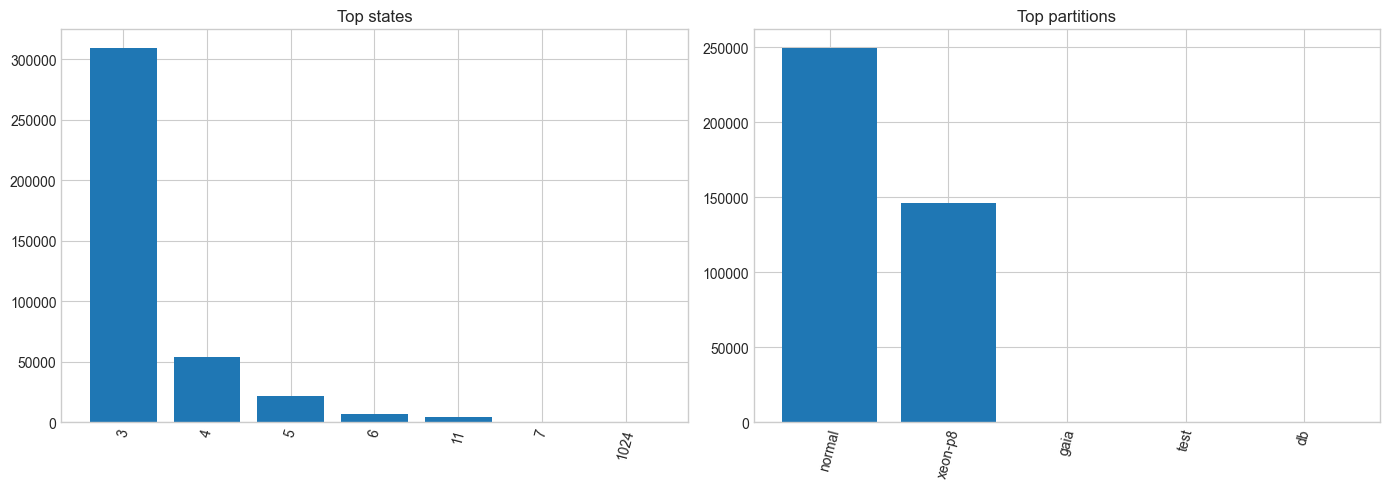

In [4]:
state_dist = slurm['state'].value_counts(dropna=False).head(15)
partition_dist = slurm['partition'].value_counts(dropna=False).head(10)

display(state_dist.rename('count').to_frame())
display(partition_dist.rename('count').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(state_dist.index.astype(str), state_dist.values)
axes[0].set_title('Top states')
axes[0].tick_params(axis='x', rotation=75)

axes[1].bar(partition_dist.index.astype(str), partition_dist.values)
axes[1].set_title('Top partitions')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

In [5]:
numeric_cols = [c for c in ['cpus_req', 'nodes_alloc', 'priority', 'wait_minutes', 'run_minutes'] if c in slurm.columns]
display(slurm[numeric_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

,count,mean,std,min,50%,90%,95%,99%,max
cpus_req,395914.0,9.233937,63.951753,1.0,4.00,20.000,32.000000,64.000000,8480.0
nodes_alloc,395914.0,1.146747,8.362052,1.0,1.00,1.000,1.000000,2.000000,891.0
priority,395914.0,15931.155372,23190.402471,10002.0,10195.00,10699.000,110060.000000,110675.000000,119999.0
wait_minutes,395914.0,283.796948,874.020158,0.0,4.55,664.195,1709.045000,4323.751500,25279.0
run_minutes,395914.0,372.463605,1477.450731,5.0,44.00,720.350,1440.433333,5948.527667,56118.9


## 3) Join voi labels de phan tich theo model

In [6]:
merged = slurm.merge(labels, on='id_job', how='left')
merged['has_label'] = merged['model'].notna()

coverage = merged['has_label'].value_counts().rename(index={True: 'labelled', False: 'unlabelled'}).to_frame('rows')
coverage['ratio_percent'] = (coverage['rows'] / len(merged) * 100).round(2)
display(coverage)

job_level = merged.groupby('id_job', as_index=False).agg(has_label=('has_label', 'max'))
job_cov = job_level['has_label'].value_counts().rename(index={True: 'labelled', False: 'unlabelled'}).to_frame('unique_jobs')
job_cov['ratio_percent'] = (job_cov['unique_jobs'] / len(job_level) * 100).round(2)
display(job_cov)

,rows,ratio_percent
has_label,,
unlabelled,392484,99.13
labelled,3430,0.87


,unique_jobs,ratio_percent
has_label,,
unlabelled,392484,99.13
labelled,3430,0.87


In [7]:
labelled = merged[merged['has_label']].copy()

agg = labelled.groupby('model').agg(
    rows=('id_job', 'size'),
    unique_jobs=('id_job', 'nunique'),
    median_wait_min=('wait_minutes', 'median'),
    p90_wait_min=('wait_minutes', lambda s: s.quantile(0.9)),
    median_run_min=('run_minutes', 'median'),
    p90_run_min=('run_minutes', lambda s: s.quantile(0.9)),
    median_cpus=('cpus_req', 'median')
).sort_values('unique_jobs', ascending=False)

display(agg.round(2))

,rows,unique_jobs,median_wait_min,p90_wait_min,median_run_min,p90_run_min,median_cpus
model,,,,,,,
inception4,243,243,947.03,2131.99,326.65,1175.50,40.0
inception3,241,241,478.57,1802.75,179.40,630.38,40.0
vgg19,199,199,998.95,2644.16,306.60,1142.20,40.0
bert-base-uncased,189,189,542.98,1039.08,82.08,314.37,40.0
vgg11,185,185,721.00,2564.09,188.87,673.17,40.0
vgg16,176,176,196.58,1199.62,278.11,929.55,40.0
distilbert-base-uncased,172,172,282.65,778.15,45.09,183.02,40.0
U3-128,165,165,425.98,1742.84,173.88,739.79,40.0
U3-32,165,165,1720.70,3972.98,50.55,608.80,40.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_26048\2781150402.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


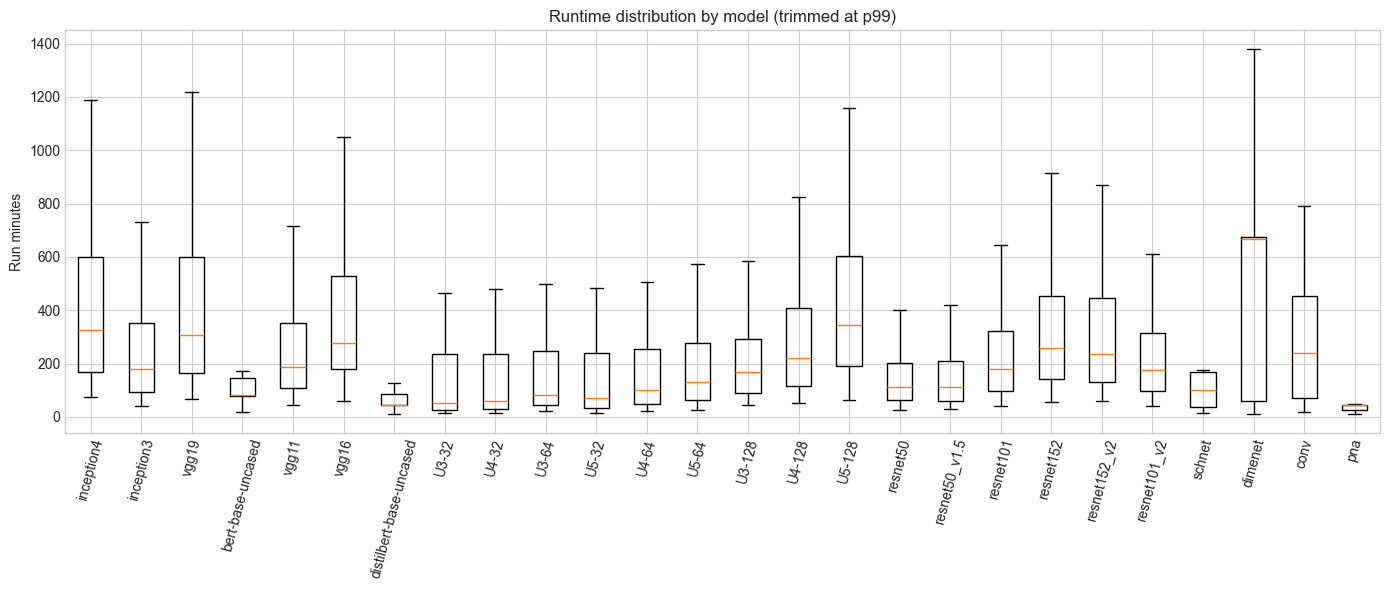

In [8]:
# Cat outlier de plot de doc hon
plot_df = labelled.copy()
plot_df = plot_df[plot_df['run_minutes'].notna()]
upper = plot_df['run_minutes'].quantile(0.99)
plot_df = plot_df[plot_df['run_minutes'] <= upper]

order = plot_df['model'].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
data = [plot_df.loc[plot_df['model'] == m, 'run_minutes'].values for m in order]
ax.boxplot(data, labels=order, showfliers=False)
ax.set_title('Runtime distribution by model (trimmed at p99)')
ax.set_ylabel('Run minutes')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

state,3,6,4
model,,,
U3-128,100.00,0.00,0.00
U3-32,100.00,0.00,0.00
U3-64,100.00,0.00,0.00
U4-128,100.00,0.00,0.00
U4-32,100.00,0.00,0.00
U4-64,100.00,0.00,0.00
U5-128,100.00,0.00,0.00
U5-32,100.00,0.00,0.00
U5-64,100.00,0.00,0.00


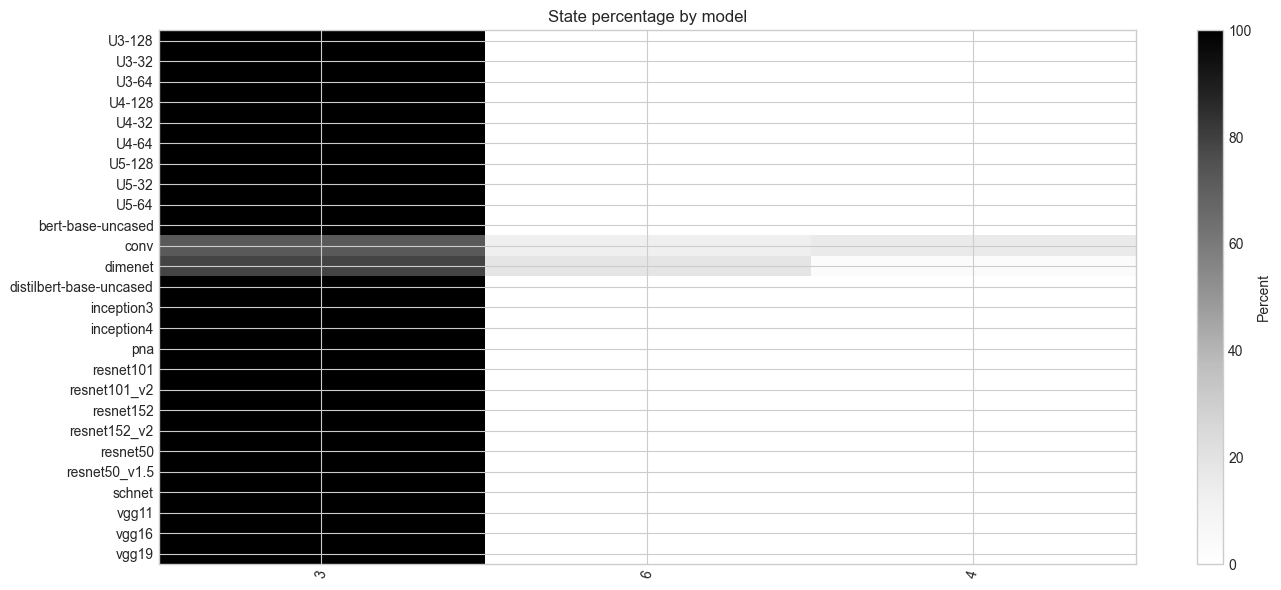

In [9]:
state_by_model = pd.crosstab(labelled['model'], labelled['state'], normalize='index').mul(100).round(2)
top_states = labelled['state'].value_counts().head(8).index
state_by_model = state_by_model.reindex(columns=top_states, fill_value=0)
display(state_by_model)

fig, ax = plt.subplots(figsize=(14, 6))
img = ax.imshow(state_by_model.values, aspect='auto')
ax.set_title('State percentage by model')
ax.set_xticks(np.arange(len(state_by_model.columns)))
ax.set_xticklabels(state_by_model.columns, rotation=75)
ax.set_yticks(np.arange(len(state_by_model.index)))
ax.set_yticklabels(state_by_model.index)
cbar = fig.colorbar(img, ax=ax)
cbar.set_label('Percent')
plt.tight_layout()
plt.show()

## 4) Quan sat chinh

- Relationship duoc noi qua `id_job`, co the la 1-n khi len cap row slurm.
- `run_minutes` va `wait_minutes` cho phep so sanh hanh vi scheduling giua cac model.
- Bang `state_by_model` cho thay model nao de gap state bat thuong hon.